In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Laptop_price.csv to Laptop_price (1).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv("Laptop_price.csv")



# Check the head of customers, and check out its info() and describe() methods.







In [ ]:
df.head()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718


# Check the Tail as well,to know the maximum entries in the data

In [ ]:
df.tail()

,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
995,HP,3.343584,4,1000,12.587095,3.162399,31593.668017
996,Dell,2.780555,8,256,12.679356,3.750265,9149.521832
997,Dell,3.200569,4,512,12.666315,3.392612,16552.404779
998,Asus,1.604182,8,256,11.215581,3.857613,9407.473459
999,Lenovo,1.711980,4,256,16.561498,3.440883,8807.696702


In [ ]:
df.describe()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB


In [ ]:
df.isnull().sum()

,0
Brand,0
Processor_Speed,0
RAM_Size,0
Storage_Capacity,0
Screen_Size,0
Weight,0
Price,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df_encoded=pd.get_dummies(df,columns=['Brand'],drop_first=True)
df_encoded.head()

,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price,Brand_Asus,Brand_Dell,Brand_HP,Brand_Lenovo
0,3.830296,16,512,11.185147,2.641094,17395.093065,True,False,False,False
1,2.912833,4,1000,11.311372,3.260012,31607.605919,False,False,False,False
2,3.241627,4,256,11.853023,2.029061,9291.023542,False,False,False,True
3,3.806248,16,512,12.280360,4.573865,17436.728334,False,False,False,False
4,3.268097,32,1000,14.990877,4.193472,32917.990718,False,False,False,False



# Exploratory Data Analysis
# Let's explore the data!

# For the rest of the exercise we'll only be using the numerical data of the csv file.

# Here we want to see the price range of the laptops.We will be using a Histogram here

Text(0, 0.5, 'Frequency')

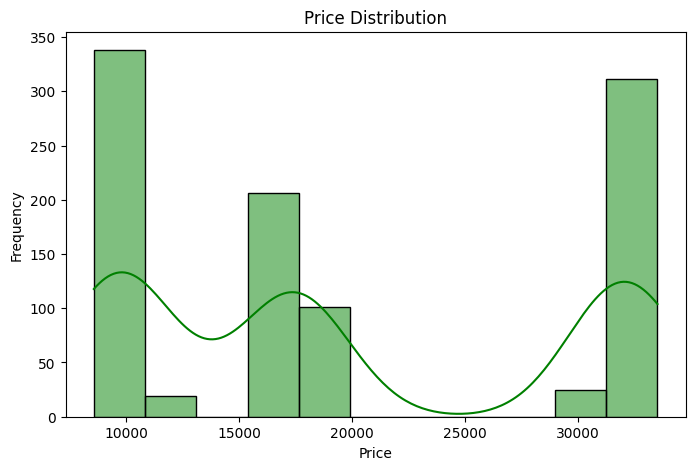

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Price'],kde=True,color='Green')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')

# Correlation Matrix-This would help us to know the relation of the features with the price

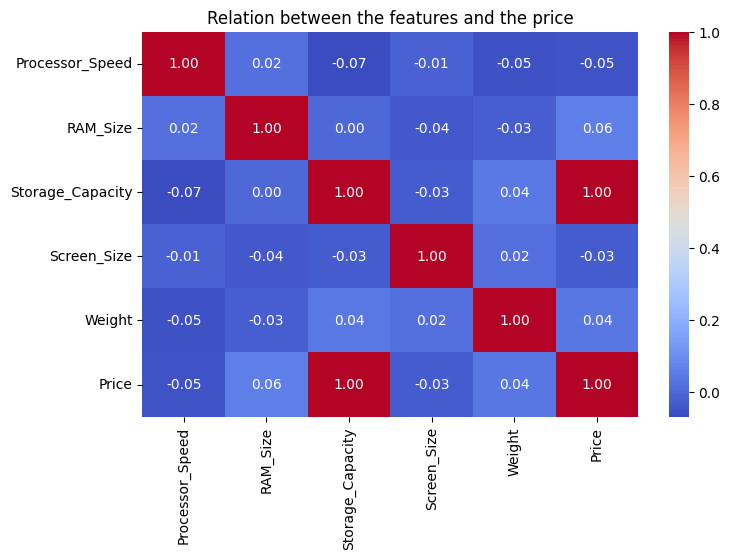

In [ ]:
plt.figure(figsize=(8,5))
numeric_df=df.select_dtypes(include=['float64','float32','int32','int64'])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Relation between the features and the price')
sns.set(font_scale=1.2)
plt.show()


# Here we would make scatter plot between RAM and Price,actually scatterplot is made to know the relationship between the two features.

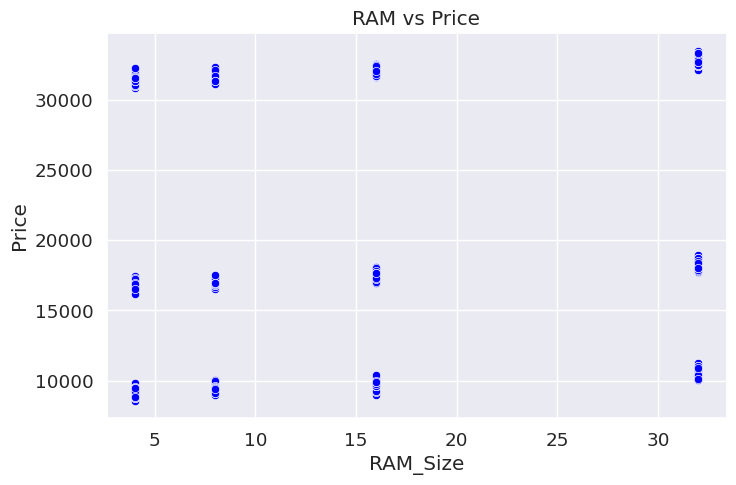

In [ ]:
plt.figure(figsize=(8,5))
# plt.subplot(1, 2, 1)
sns.scatterplot(data=df,x="RAM_Size",y="Price",color="Blue")
plt.title('RAM vs Price')
plt.show()

# ScatterPlot between Storage Capacity and Price

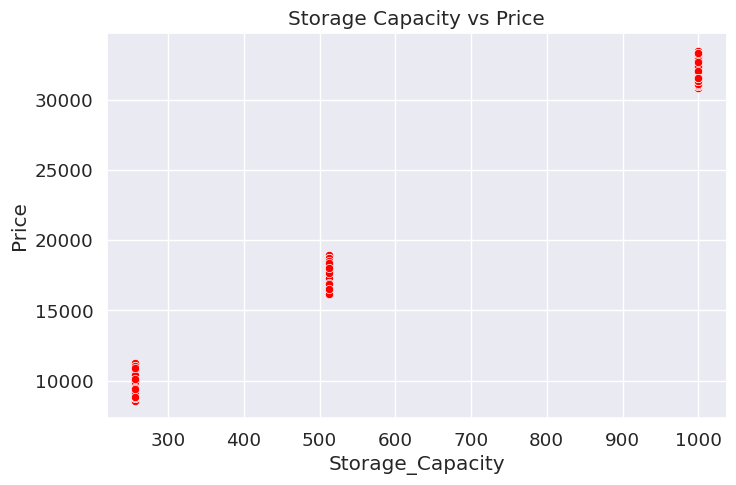

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Storage_Capacity",y="Price",color="red")
plt.title('Storage Capacity vs Price')
plt.show()

# Here comes the Linear Regression

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

X=df_encoded.drop('Price',axis=1)
y=df_encoded['Price']

# Trainig and testing split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# linear regression is being used over here.
model=LinearRegression()
model.fit(X_train_scaled,y_train)


y_pred=model.predict(X_test_scaled)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f"Mean Squared Error:{mse:.4f}")
print(f"R-squared:{r2:.4f}")


Mean Squared Error:32304.7373
R-squared:0.9996


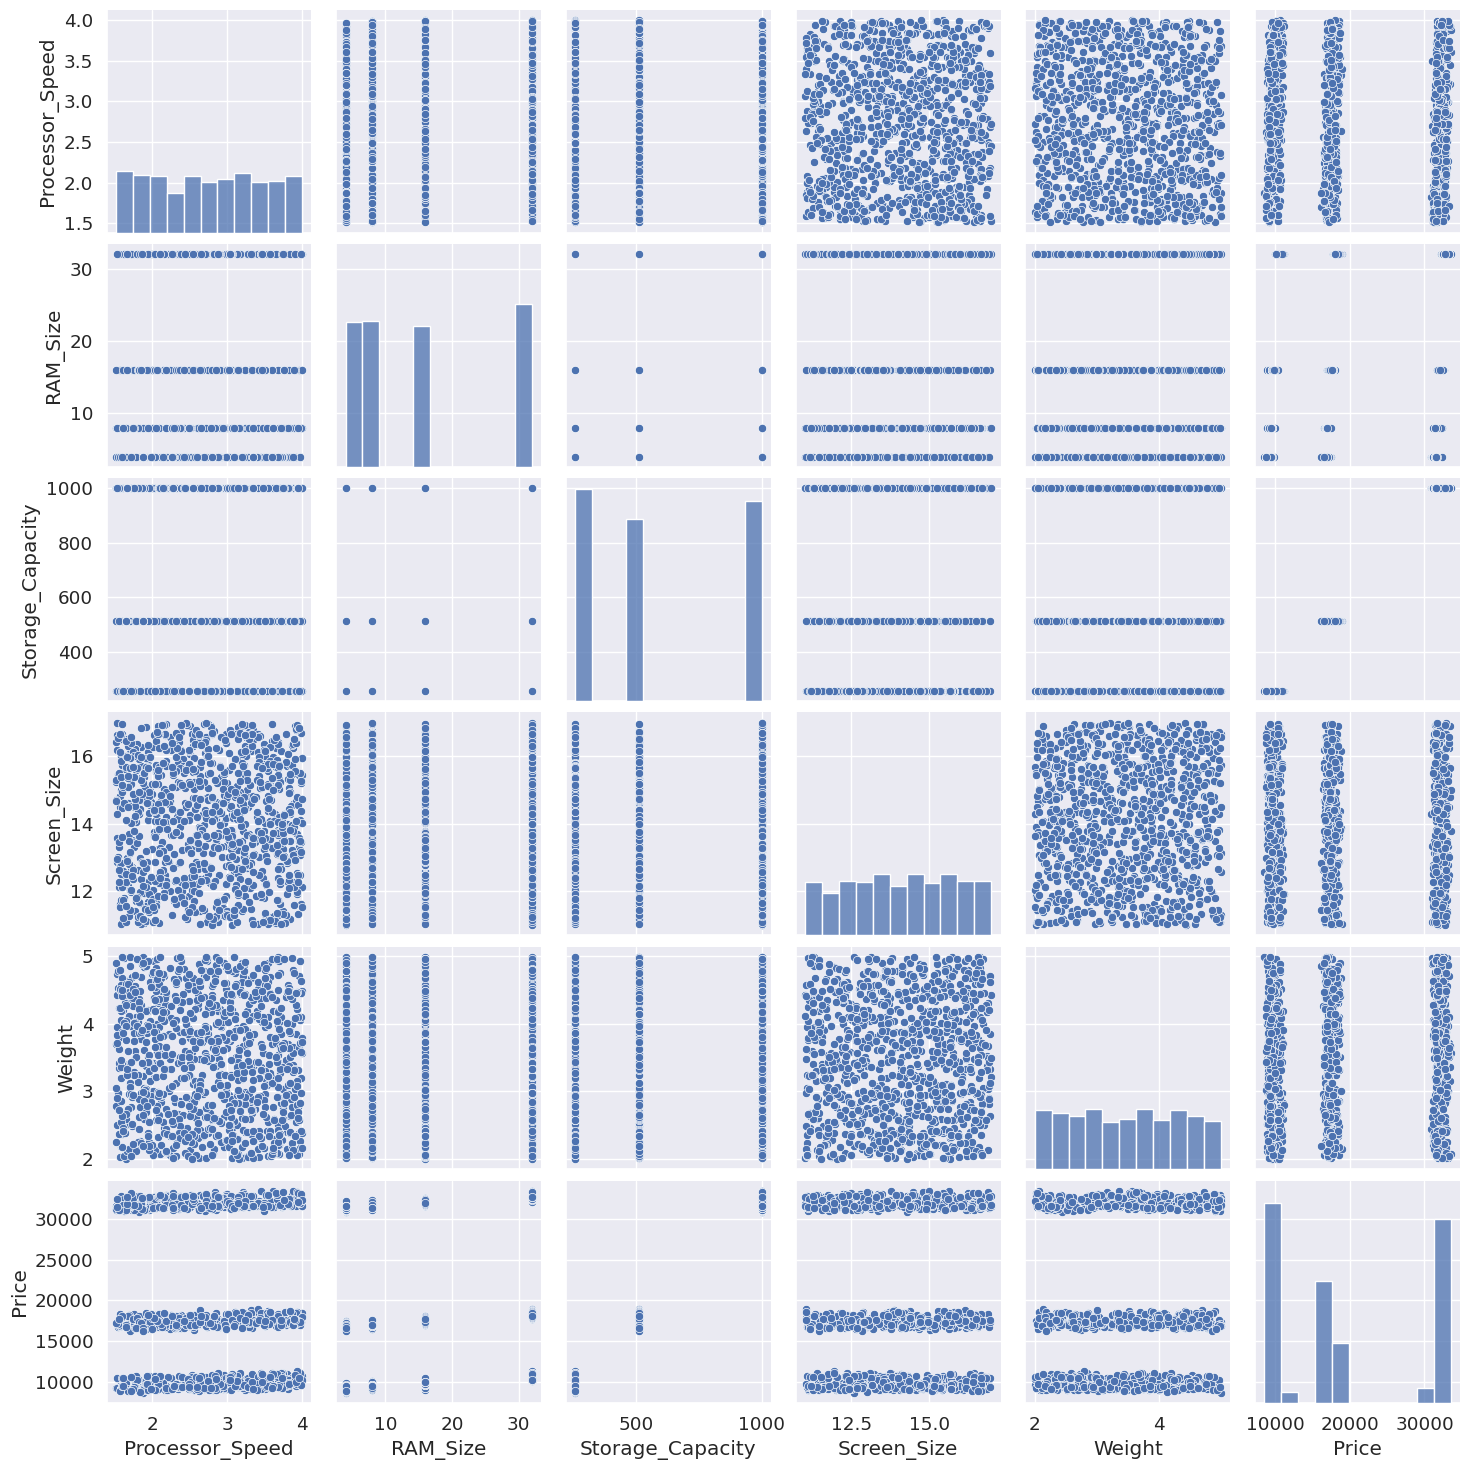

In [ ]:
sns.pairplot(df)
plt.show()

# Create a scatterplot of the real test values vs the predicted values

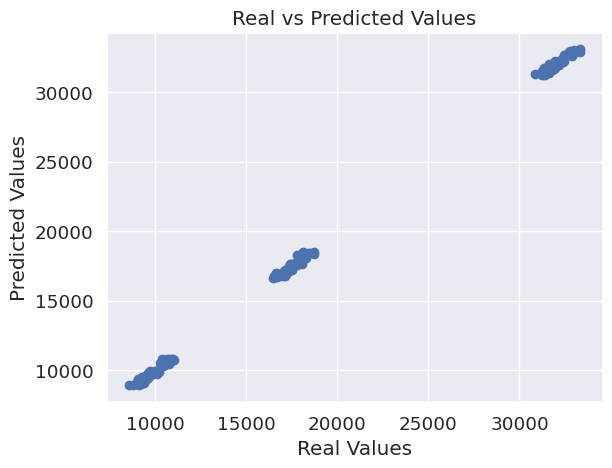

In [ ]:
plt.scatter(y_test,y_pred)
plt.xlabel('Real Values')
plt.ylabel('Predicted Values')
plt.title('Real vs Predicted Values')
plt.show()

#
# Residuals
# You should have gotten a very good model with a good fit. Let's quickly explore the residuals to make sure everything was okay with our data

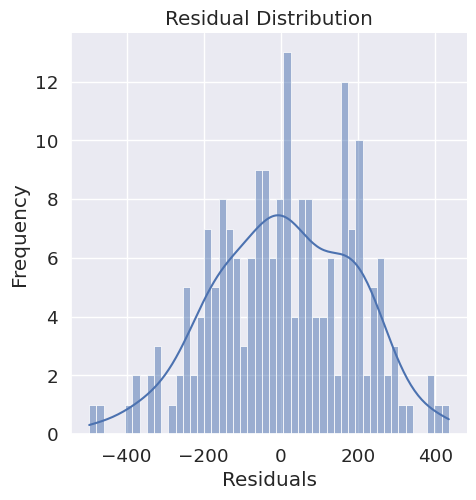

In [ ]:
sns.displot(y_test-y_pred,bins=50,kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()